# Baixar o Dataset e Extrair os Pontos

In [ ]:
%%time
import os
import cv2
import numpy as np
import mediapipe as mp
import pandas as pd
import kagglehub
import joblib
import time
from sklearn.preprocessing import StandardScaler

print("1. A transferir o dataset do Kaggle...")
path = kagglehub.dataset_download("williansoliveira/libras")
caminho_train = os.path.join(path, "train")
caminho_test = os.path.join(path, "test")

print("2. A iniciar o MediaPipe...")
mp_maos = mp.solutions.hands
detector_maos = mp_maos.Hands(static_image_mode=True, max_num_hands=1, min_detection_confidence=0.5)

def extrair_pontos(caminho_base):
    dados_X = []
    dados_y = []
    for letra in os.listdir(caminho_base):
        caminho_pasta_letra = os.path.join(caminho_base, letra)
        if not os.path.isdir(caminho_pasta_letra): continue
        
        for nome_arquivo in os.listdir(caminho_pasta_letra):
            caminho_imagem = os.path.join(caminho_pasta_letra, nome_arquivo)
            imagem = cv2.imread(caminho_imagem)
            if imagem is None: continue
            
            imagem_rgb = cv2.cvtColor(imagem, cv2.COLOR_BGR2RGB)
            resultados = detector_maos.process(imagem_rgb)
            
            if resultados.multi_hand_landmarks:
                for landmarks in resultados.multi_hand_landmarks:
                    # 1. Normalização de Posição (Subtrair o Pulso)
                    pulso_x = landmarks.landmark[0].x
                    pulso_y = landmarks.landmark[0].y
                    pulso_z = landmarks.landmark[0].z
                    
                    linha_temp = []
                    for ponto in landmarks.landmark:
                        linha_temp.extend([
                            ponto.x - pulso_x, 
                            ponto.y - pulso_y, 
                            ponto.z - pulso_z
                        ])
                    
                    # Normalização de Escala (Proporção)
                    # Encontra a maior distância absoluta desta mão
                    valor_maximo = max(map(abs, linha_temp))
                    if valor_maximo == 0: valor_maximo = 1.0 # Evitar divisão por zero
                    
                    # Divide todos os valores pelo valor máximo
                    linha_normalizada = [valor / valor_maximo for valor in linha_temp]
                    
                    dados_X.append(linha_normalizada)
                    dados_y.append(letra)
                    
    return np.array(dados_X), np.array(dados_y)

print("3. A extrair coordenadas do TREINO...")
inicio_treino = time.time()
X_train_bruto, y_train = extrair_pontos(caminho_train)
fim_treino = time.time()
print(f"   Concluído em {(fim_treino - inicio_treino):.2f} segundos.")

print("4. A extrair coordenadas do TESTE...")
inicio_teste = time.time()
X_test_bruto, y_test = extrair_pontos(caminho_test)
fim_teste = time.time()
print(f"   Concluído em {(fim_teste - inicio_teste):.2f} segundos.")

print("5. A padronizar a escala dos dados...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bruto)
X_test_scaled = scaler.transform(X_test_bruto)

print("6. A criar ficheiro de backup no disco...")
dados_ambiente = {
    'X_train': X_train_scaled,
    'X_test': X_test_scaled,
    'y_train': y_train,
    'y_test': y_test
}

joblib.dump(dados_ambiente, 'dados_ambiente.pkl')
joblib.dump(scaler, 'scaler_libras.pkl') 

print("✓ Sucesso! Divisão original do Kaggle respeitada.")
print(f"Tamanho do treino: {X_train_scaled.shape[0]} amostras.")
print(f"Tamanho do teste: {X_test_scaled.shape[0]} amostras.")

1. A transferir o dataset do Kaggle...
2. A iniciar o MediaPipe...
3. A extrair coordenadas do TREINO...


c:\Users\yujif\AppData\Local\Programs\Python\Python312\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


   Concluído em 982.15 segundos.
4. A extrair coordenadas do TESTE...
   Concluído em 321.40 segundos.
5. A padronizar a escala dos dados...
6. A criar ficheiro de backup no disco...
✓ Sucesso! Divisão original do Kaggle respeitada.
Tamanho do treino: 34374 amostras.
Tamanho do teste: 11431 amostras.
CPU times: total: 22min 5s
Wall time: 21min 44s


# Treinamento da Rede Neural (MLP)

In [ ]:
import time
import joblib
from sklearn.neural_network import MLPClassifier

print("A recuperar dados do backup...")
dados = joblib.load('dados_ambiente.pkl')
X_train_scaled, y_train = dados['X_train'], dados['y_train']

print("A iniciar Treinamento da IA 1: Rede Neural (MLP)...")
tempo_inicio = time.time()

modelo_mlp = MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=1000, random_state=42)
modelo_mlp.fit(X_train_scaled, y_train)

tempo_fim = time.time()
print(f"✓ Treinamento concluído em {(tempo_fim - tempo_inicio):.2f} segundos.")

joblib.dump(modelo_mlp, 'modelo_mlp.pkl')
print("Modelo arquivado como 'modelo_mlp.pkl'.")

A recuperar dados do backup...
A iniciar Treinamento da IA 1: Rede Neural (MLP)...
✓ Treinamento concluído em 11.33 segundos.
Modelo arquivado como 'modelo_mlp.pkl'.


# Treinamento do Random Forest

In [20]:
import time
import joblib
from sklearn.ensemble import RandomForestClassifier

print("A recuperar dados do backup...")
dados = joblib.load('dados_ambiente.pkl')
X_train_scaled, y_train = dados['X_train'], dados['y_train']

print("A iniciar Treinamento da IA 2: Random Forest...")
tempo_inicio = time.time()

modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
modelo_rf.fit(X_train_scaled, y_train)

tempo_fim = time.time()
print(f"✓ Treinamento concluído em {(tempo_fim - tempo_inicio):.2f} segundos.")

joblib.dump(modelo_rf, 'modelo_rf.pkl')
print("Modelo arquivado como 'modelo_rf.pkl'.")

A recuperar dados do backup...
A iniciar Treinamento da IA 2: Random Forest...
✓ Treinamento concluído em 1.84 segundos.
Modelo arquivado como 'modelo_rf.pkl'.


# Treinamento do SVM

In [4]:
import time
import joblib
from sklearn.svm import SVC

print("A recuperar dados do backup para o SVM...")
dados = joblib.load('dados_ambiente.pkl')
X_train_scaled, y_train = dados['X_train'], dados['y_train']

print("A iniciar Treinamento da IA 3: SVM (Support Vector Machine)...")
tempo_inicio = time.time()

# O parâmetro probability=True é obrigatório para que a câmara possa calcular a % de certeza depois
modelo_svm = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
modelo_svm.fit(X_train_scaled, y_train)

tempo_fim = time.time()
print(f"✓ Treinamento concluído em {(tempo_fim - tempo_inicio):.2f} segundos.")

joblib.dump(modelo_svm, 'modelo_svm.pkl')
print("Modelo arquivado como 'modelo_svm.pkl'.")

A recuperar dados do backup para o SVM...
A iniciar Treinamento da IA 3: SVM (Support Vector Machine)...


c:\Users\yujif\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


✓ Treinamento concluído em 8.74 segundos.
Modelo arquivado como 'modelo_svm.pkl'.


# Avaliação e Resultados Visuais

A carregar o conjunto de testes e os 3 modelos...

--- DESEMPENHO DA REDE NEURAL (MLP) ---
Acurácia Final: 99.65% | Loss Final: 0.0002

--- DESEMPENHO DO RANDOM FOREST ---
Acurácia Final: 99.77%

--- DESEMPENHO DO SVM ---
Acurácia Final: 99.43%

O VENCEDOR ABSOLUTO É: Random Forest com 99.77% de acurácia!
Ficheiro definitivo 'modelo_libras_pontos_final.pkl' atualizado para a câmara.

A gerar gráficos e matrizes de análise...


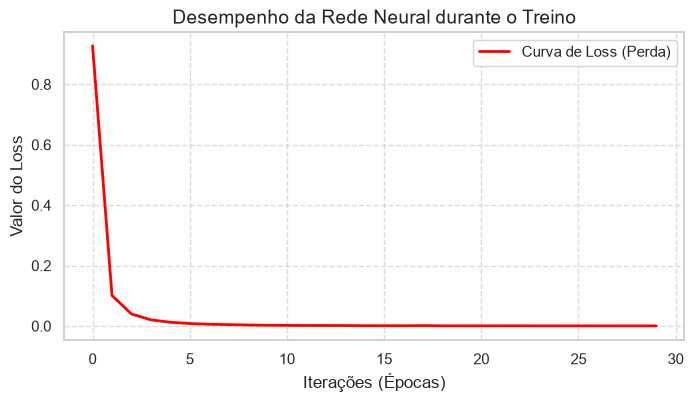

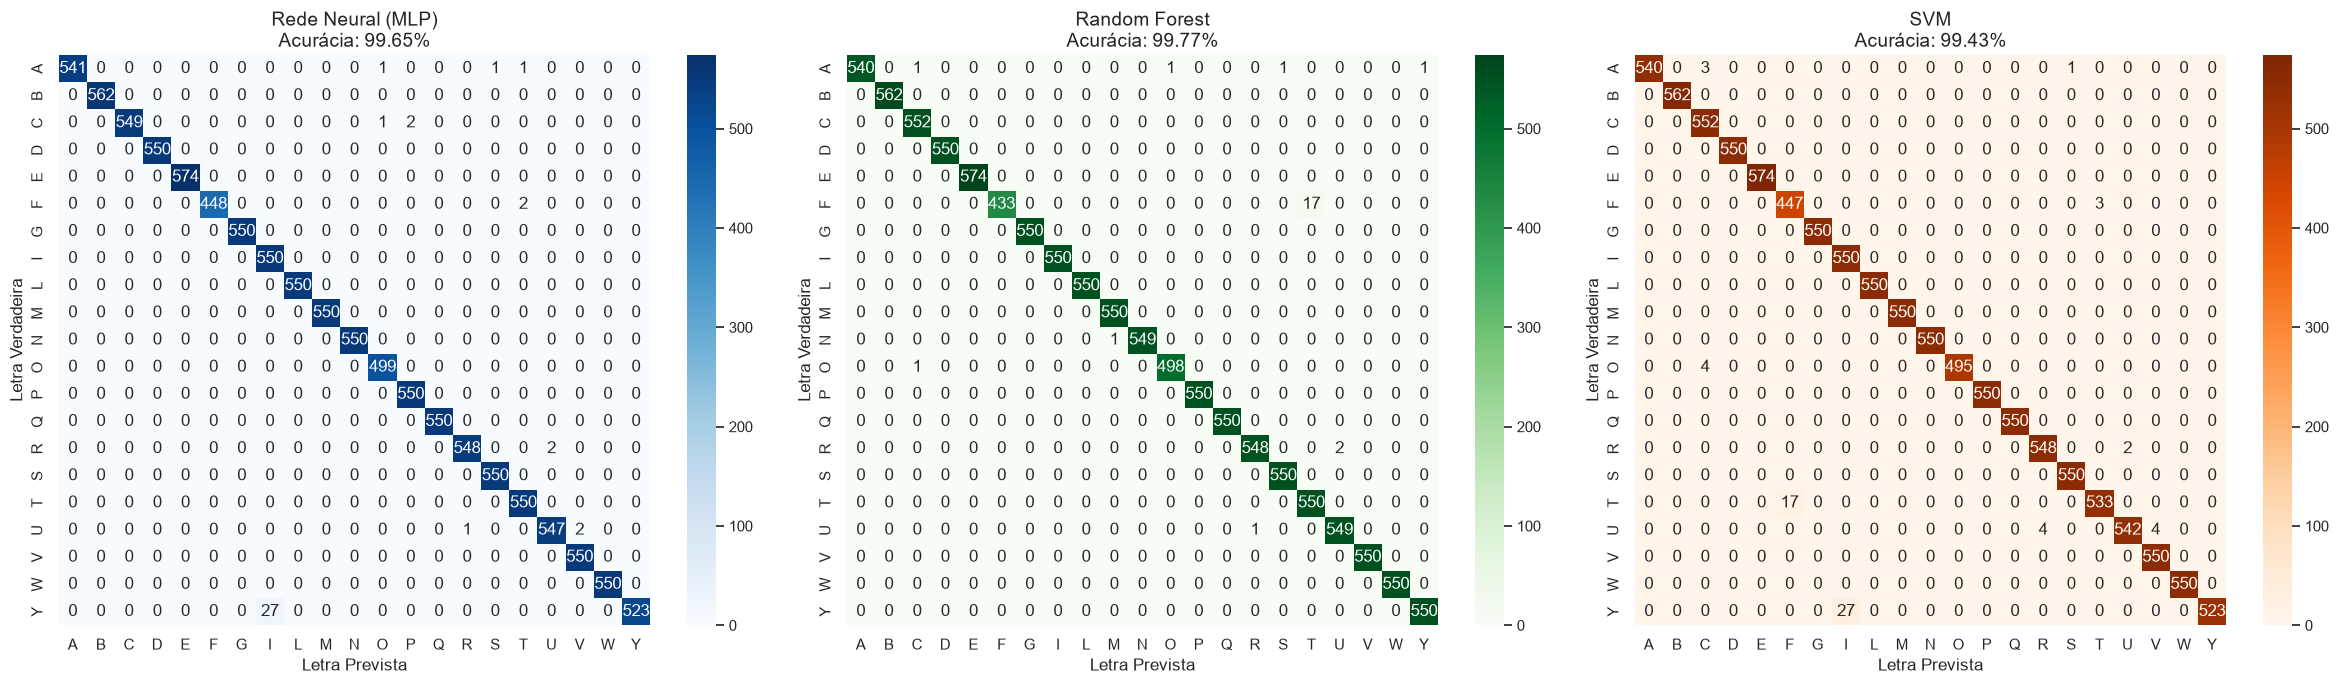

Gerando Mapa de Atenção (Feature Importance) do Random Forest...


C:\Users\yujif\AppData\Local\Temp\ipykernel_2680\2825721046.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancia_por_ponto, y=nomes_pontos, palette="magma")


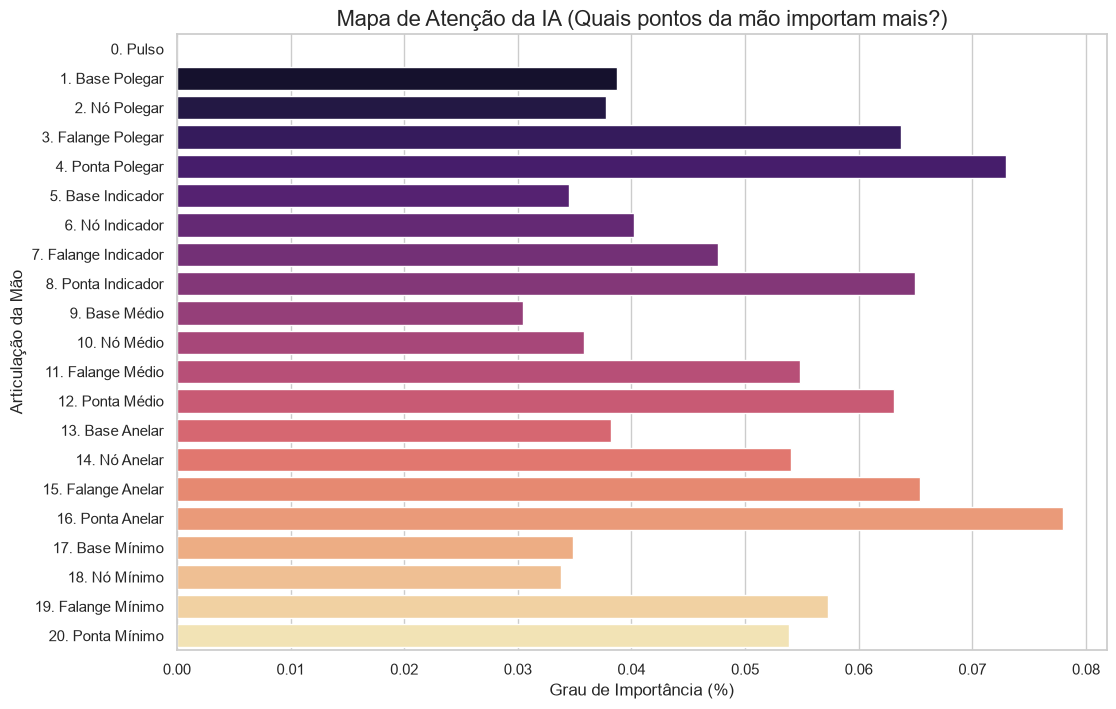

✓ Todos os gráficos foram salvos na pasta 'resultados_visuais'!

RELATÓRIO DE CLASSIFICAÇÃO - VENCEDOR (Random Forest)
              precision    recall  f1-score   support

           A       1.00      0.99      1.00       544
           B       1.00      1.00      1.00       562
           C       1.00      1.00      1.00       552
           D       1.00      1.00      1.00       550
           E       1.00      1.00      1.00       574
           F       1.00      0.96      0.98       450
           G       1.00      1.00      1.00       550
           I       1.00      1.00      1.00       550
           L       1.00      1.00      1.00       550
           M       1.00      1.00      1.00       550
           N       1.00      1.00      1.00       550
           O       1.00      1.00      1.00       499
           P       1.00      1.00      1.00       550
           Q       1.00      1.00      1.00       550
           R       1.00      1.00      1.00       550
           S    

In [6]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("A carregar o conjunto de testes e os 3 modelos...\n")
dados = joblib.load('dados_ambiente.pkl')
X_test_scaled, y_test = dados['X_test'], dados['y_test']

modelo_mlp = joblib.load('modelo_mlp.pkl')
modelo_rf = joblib.load('modelo_rf.pkl')
modelo_svm = joblib.load('modelo_svm.pkl')

pasta_resultados = "resultados_visuais"
os.makedirs(pasta_resultados, exist_ok=True)

# PREVISÕES E MÉTRICAS BÁSICAS

# 1. MLP
y_pred_mlp = modelo_mlp.predict(X_test_scaled)
acc_mlp = accuracy_score(y_test, y_pred_mlp)
loss_mlp = modelo_mlp.loss_ 
print("--- DESEMPENHO DA REDE NEURAL (MLP) ---")
print(f"Acurácia Final: {acc_mlp * 100:.2f}% | Loss Final: {loss_mlp:.4f}\n")

# 2. RANDOM FOREST
y_pred_rf = modelo_rf.predict(X_test_scaled)
acc_rf = accuracy_score(y_test, y_pred_rf)
print("--- DESEMPENHO DO RANDOM FOREST ---")
print(f"Acurácia Final: {acc_rf * 100:.2f}%\n")

# 3. SVM
y_pred_svm = modelo_svm.predict(X_test_scaled)
acc_svm = accuracy_score(y_test, y_pred_svm)
print("--- DESEMPENHO DO SVM ---")
print(f"Acurácia Final: {acc_svm * 100:.2f}%\n")

# SELEÇÃO DO MODELO VENCEDOR
dicionario_resultados = {
    'Rede Neural MLP': (acc_mlp, modelo_mlp),
    'Random Forest': (acc_rf, modelo_rf),
    'SVM': (acc_svm, modelo_svm)
}

nome_vencedor = max(dicionario_resultados, key=lambda k: dicionario_resultados[k][0])
acc_vencedor, modelo_vencedor = dicionario_resultados[nome_vencedor]

print(f"O VENCEDOR ABSOLUTO É: {nome_vencedor} com {acc_vencedor * 100:.2f}% de acurácia!")
joblib.dump(modelo_vencedor, 'modelo_libras_pontos_final.pkl')
print("Ficheiro definitivo 'modelo_libras_pontos_final.pkl' atualizado para a câmara.\n")

# GRÁFICOS PARA O RELATÓRIO
print("A gerar gráficos e matrizes de análise...")

# 1. Gráfico da Curva de Loss (Apenas Rede Neural)
plt.figure(figsize=(8, 4))
plt.plot(modelo_mlp.loss_curve_, label='Curva de Loss (Perda)', color='red', linewidth=2)
plt.title('Desempenho da Rede Neural durante o Treino', fontsize=14)
plt.xlabel('Iterações (Épocas)', fontsize=12)
plt.ylabel('Valor do Loss', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# 2. Matrizes de Confusão (Três lado a lado)
fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# Matriz MLP
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues', xticklabels=modelo_mlp.classes_, yticklabels=modelo_mlp.classes_, ax=axes[0])
axes[0].set_title(f'Rede Neural (MLP)\nAcurácia: {acc_mlp*100:.2f}%', fontsize=14)

# Matriz RF
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', xticklabels=modelo_rf.classes_, yticklabels=modelo_rf.classes_, ax=axes[1])
axes[1].set_title(f'Random Forest\nAcurácia: {acc_rf*100:.2f}%', fontsize=14)

# Matriz SVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges', xticklabels=modelo_svm.classes_, yticklabels=modelo_svm.classes_, ax=axes[2])
axes[2].set_title(f'SVM\nAcurácia: {acc_svm*100:.2f}%', fontsize=14)

for ax in axes:
    ax.set_ylabel('Letra Verdadeira')
    ax.set_xlabel('Letra Prevista')

plt.tight_layout()
plt.show()

# 3. Salvar Matrizes Individualmente
def salvar_matriz(modelo, y_pred, nome_arquivo, cor):
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cor, xticklabels=modelo.classes_, yticklabels=modelo.classes_)
    plt.title(f'Matriz de Confusão - {type(modelo).__name__}', fontsize=14)
    plt.ylabel('Letra Verdadeira')
    plt.xlabel('Letra Prevista')
    plt.savefig(os.path.join(pasta_resultados, nome_arquivo), bbox_inches='tight', dpi=300)
    plt.close()

salvar_matriz(modelo_mlp, y_pred_mlp, 'matriz_confusao_mlp.png', 'Blues')
salvar_matriz(modelo_rf, y_pred_rf, 'matriz_confusao_rf.png', 'Greens')
salvar_matriz(modelo_svm, y_pred_svm, 'matriz_confusao_svm.png', 'Oranges')

# 4. O Mapa de Calor do Random Forest (Feature Importance)
print("Gerando Mapa de Atenção (Feature Importance) do Random Forest...")
importancias_brutas = modelo_rf.feature_importances_
importancia_por_ponto = [importancias_brutas[i*3] + importancias_brutas[i*3+1] + importancias_brutas[i*3+2] for i in range(21)]

nomes_pontos = [
    "0. Pulso", "1. Base Polegar", "2. Nó Polegar", "3. Falange Polegar", "4. Ponta Polegar",
    "5. Base Indicador", "6. Nó Indicador", "7. Falange Indicador", "8. Ponta Indicador",
    "9. Base Médio", "10. Nó Médio", "11. Falange Médio", "12. Ponta Médio",
    "13. Base Anelar", "14. Nó Anelar", "15. Falange Anelar", "16. Ponta Anelar",
    "17. Base Mínimo", "18. Nó Mínimo", "19. Falange Mínimo", "20. Ponta Mínimo"
]

plt.figure(figsize=(12, 8))
sns.barplot(x=importancia_por_ponto, y=nomes_pontos, palette="magma")
plt.title('Mapa de Atenção da IA (Quais pontos da mão importam mais?)', fontsize=16)
plt.xlabel('Grau de Importância (%)', fontsize=12)
plt.ylabel('Articulação da Mão', fontsize=12)
plt.savefig(os.path.join(pasta_resultados, 'mapa_atencao_rf.png'), bbox_inches='tight', dpi=300)
plt.show()

print(f"✓ Todos os gráficos foram salvos na pasta '{pasta_resultados}'!")

# RELATÓRIOS ESTATÍSTICOS DETALHADOS
print("\n" + "="*60)
print(f"RELATÓRIO DE CLASSIFICAÇÃO - VENCEDOR ({nome_vencedor})")
print("="*60)
y_pred_vencedor = modelo_vencedor.predict(X_test_scaled)
print(classification_report(y_test, y_pred_vencedor))

# 30x Execuções

In [1]:
import joblib
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
import time

print("A carregar os dados base...")
dados = joblib.load('dados_ambiente.pkl')
# Para as 30 execuções, juntamos todo o dataset para fatiá-lo aleatoriamente 30 vezes
X_total = np.vstack((dados['X_train'], dados['X_test']))
y_total = np.concatenate((dados['y_train'], dados['y_test']))

# Dicionário com os 4 modelos
modelos = {
    "MLP (1 Camada Oculta)": MLPClassifier(hidden_layer_sizes=(100,), max_iter=500),
    "MLP (2 Camadas Ocultas)": MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=500),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1),
    "SVM": SVC(kernel='rbf', C=1.0)
}

resultados_acuracia = {nome: [] for nome in modelos.keys()}
tempos_execucao = {nome: [] for nome in modelos.keys()}

print("A iniciar as 30 execuções estatísticas...\n")

for semente in range(30):
    if (semente+1) % 5 == 0:
        print(f"Execução {semente+1}/30 em andamento...")
        
    X_train, X_test, y_train, y_test = train_test_split(
        X_total, y_total, test_size=0.2, random_state=semente
    )
    
    for nome, modelo in modelos.items():
        inicio = time.time()
        modelo.fit(X_train, y_train) # Treina
        fim = time.time()
        
        previsao = modelo.predict(X_test)
        acuracia = accuracy_score(y_test, previsao)
        
        resultados_acuracia[nome].append(acuracia)
        tempos_execucao[nome].append(fim - inicio)

print("\n" + "="*50)
print("RESULTADOS ESTATÍSTICOS FINAIS")
print("="*50)

for nome in modelos.keys():
    media_acc = np.mean(resultados_acuracia[nome]) * 100
    desvio_acc = np.std(resultados_acuracia[nome]) * 100
    media_tempo = np.mean(tempos_execucao[nome])
    
    print(f"Modelo: {nome}")
    print(f"  Acurácia: {media_acc:.2f}% ± {desvio_acc:.2f}%")
    print(f"  Tempo Médio: {media_tempo:.4f} segundos")
    print("-" * 30)

A carregar os dados base...
A iniciar as 30 execuções estatísticas...

Execução 5/30 em andamento...
Execução 10/30 em andamento...
Execução 15/30 em andamento...
Execução 20/30 em andamento...
Execução 25/30 em andamento...
Execução 30/30 em andamento...

RESULTADOS ESTATÍSTICOS FINAIS
Modelo: MLP (1 Camada Oculta)
  Acurácia: 99.97% ± 0.02%
  Tempo Médio: 15.1960 segundos
------------------------------
Modelo: MLP (2 Camadas Ocultas)
  Acurácia: 99.97% ± 0.02%
  Tempo Médio: 18.2535 segundos
------------------------------
Modelo: Random Forest
  Acurácia: 99.96% ± 0.02%
  Tempo Médio: 3.4892 segundos
------------------------------
Modelo: SVM
  Acurácia: 99.91% ± 0.03%
  Tempo Médio: 2.7495 segundos
------------------------------


A gerar o Boxplot comparativo das 30 execuções...


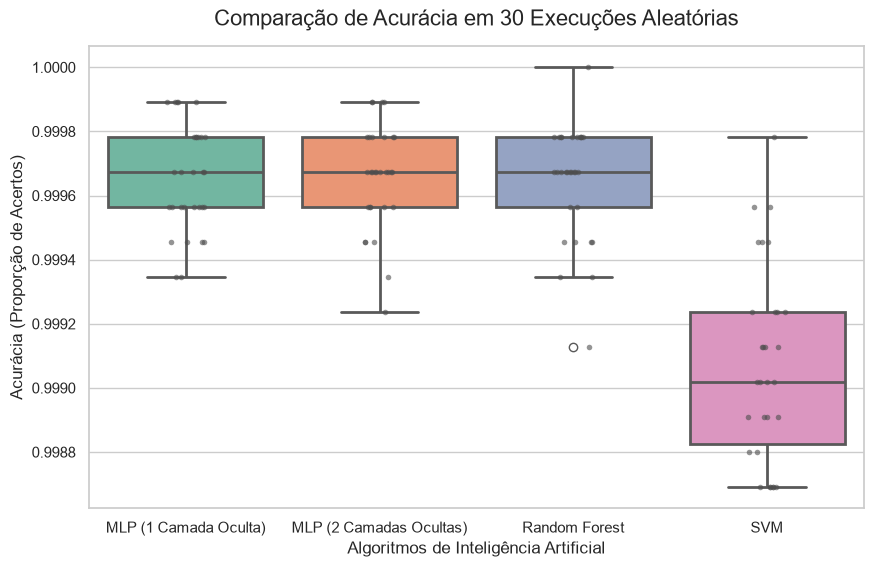

✓ Gráfico salvo com sucesso em: resultados_visuais/boxplot_comparacao_modelos.png


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("A gerar o Boxplot comparativo das 30 execuções...")

# Transforma o dicionário de resultados numa tabela (DataFrame) para facilitar o gráfico
dados_grafico = pd.DataFrame(resultados_acuracia)

# Configura o tamanho e o estilo do gráfico
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Cria o Boxplot
ax = sns.boxplot(data=dados_grafico, palette="Set2", linewidth=2)

# Adiciona os pontos reais (cada uma das 30 execuções) por cima da caixa para dar um ar mais científico
sns.stripplot(data=dados_grafico, color=".3", size=4, alpha=0.6, jitter=True)

# Títulos e Rótulos profissionais
plt.title('Comparação de Acurácia em 30 Execuções Aleatórias', fontsize=16, pad=15)
plt.ylabel('Acurácia (Proporção de Acertos)', fontsize=12)
plt.xlabel('Algoritmos de Inteligência Artificial', fontsize=12)

# Salva a imagem com qualidade de impressão (300 dpi) exigida em artigos IEEE
caminho_grafico = 'resultados_visuais/boxplot_comparacao_modelos.png'
plt.savefig(caminho_grafico, dpi=300, bbox_inches='tight')

plt.show()
print(f"✓ Gráfico salvo com sucesso em: {caminho_grafico}")